# CREDIT CARD FRAUD DETECTION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df=pd.read_csv('credit_card_fraud_dataset-5.csv')
df

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
0,1738.38,15,Travel,Amex,0,42.33,1,2648.87,1.0,0
1,1450.18,14,Retail,Visa,1,3.09,3,1754.85,0.0,0
2,923.78,20,Grocery,RuPay,1,4.88,5,4115.96,35.0,0
3,885.04,12,Utilities,Mastercard,1,6.35,6,665.16,1.0,0
4,6914.66,13,Online,Visa,1,56.09,2,12672.62,0.0,0
...,...,...,...,...,...,...,...,...,...,...
49995,1410.70,19,Utilities,Mastercard,0,14.64,4,911.48,0.0,0
49996,1368.41,16,Utilities,RuPay,1,24.89,1,2358.95,0.0,0
49997,1652.39,11,Entertainment,Mastercard,1,45.06,7,2688.45,0.0,0
49998,2900.05,19,Grocery,RuPay,1,15.60,1,2162.72,1.0,0


## Data Understanding

In [3]:
df.head()

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
0,1738.38,15,Travel,Amex,0,42.33,1,2648.87,1.0,0
1,1450.18,14,Retail,Visa,1,3.09,3,1754.85,0.0,0
2,923.78,20,Grocery,RuPay,1,4.88,5,4115.96,35.0,0
3,885.04,12,Utilities,Mastercard,1,6.35,6,665.16,1.0,0
4,6914.66,13,Online,Visa,1,56.09,2,12672.62,0.0,0


In [4]:
df.tail()

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
49995,1410.70,19,Utilities,Mastercard,0,14.64,4,911.48,0.0,0
49996,1368.41,16,Utilities,RuPay,1,24.89,1,2358.95,0.0,0
49997,1652.39,11,Entertainment,Mastercard,1,45.06,7,2688.45,0.0,0
49998,2900.05,19,Grocery,RuPay,1,15.60,1,2162.72,1.0,0
49999,2028.38,17,Retail,RuPay,1,4.75,2,1857.92,0.0,0


In [5]:
df.shape

(50000, 10)

In [6]:
df.size

500000

In [7]:
df.columns

Index(['transaction_amount_inr', 'hour_of_day', 'merchant_category',
       'card_type', 'card_present', 'distance_from_home_km',
       'transactions_last_24h', 'avg_transaction_amount_inr',
       'num_declined_last_30d', 'is_fraud'],
      dtype='object')

In [8]:
df.dtypes

transaction_amount_inr        float64
hour_of_day                     int64
merchant_category              object
card_type                      object
card_present                    int64
distance_from_home_km         float64
transactions_last_24h           int64
avg_transaction_amount_inr    float64
num_declined_last_30d         float64
is_fraud                        int64
dtype: object

In [9]:
df.describe()

,transaction_amount_inr,hour_of_day,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
count,49500.000000,50000.000000,50000.000000,49000.000000,50000.000000,49000.000000,49500.000000,50000.000000
mean,6346.155911,12.231940,0.770580,40.967681,3.624240,2190.090752,0.551737,0.085000
std,37079.162533,5.331074,0.420464,319.501827,3.728399,1592.254765,1.729375,0.278884
min,200.000000,0.000000,0.000000,0.000000,0.000000,500.000000,0.000000,0.000000
25%,1462.692500,8.000000,1.000000,4.770000,2.000000,1124.917500,0.000000,0.000000
50%,2703.425000,12.000000,1.000000,11.680000,3.000000,1766.530000,0.000000,0.000000
75%,5044.922500,16.000000,1.000000,24.570000,4.000000,2754.077500,1.000000,0.000000
max,994519.360000,23.000000,1.000000,7982.120000,89.000000,21761.930000,44.000000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   transaction_amount_inr      49500 non-null  float64
 1   hour_of_day                 50000 non-null  int64  
 2   merchant_category           49500 non-null  object 
 3   card_type                   49500 non-null  object 
 4   card_present                50000 non-null  int64  
 5   distance_from_home_km       49000 non-null  float64
 6   transactions_last_24h       50000 non-null  int64  
 7   avg_transaction_amount_inr  49000 non-null  float64
 8   num_declined_last_30d       49500 non-null  float64
 9   is_fraud                    50000 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 3.8+ MB


In [11]:
df.isna().sum()

transaction_amount_inr         500
hour_of_day                      0
merchant_category              500
card_type                      500
card_present                     0
distance_from_home_km         1000
transactions_last_24h            0
avg_transaction_amount_inr    1000
num_declined_last_30d          500
is_fraud                         0
dtype: int64

In [12]:
df['merchant_category'].unique()

array(['Travel', 'Retail', 'Grocery', 'Utilities', 'Online', 'Restaurant',
       'Entertainment', 'Electronics', 'Gas', 'Healthcare', nan],
      dtype=object)

In [13]:
df['merchant_category'].value_counts()

merchant_category
Online           9484
Grocery          9264
Restaurant       6849
Travel           4131
Electronics      3939
Retail           3870
Gas              3498
Healthcare       3358
Entertainment    3099
Utilities        2008
Name: count, dtype: int64

In [14]:
df['hour_of_day'].unique()

array([15, 14, 20, 12, 13, 17,  8,  7, 23, 18, 19, 16,  6,  0, 11, 10, 22,
        4,  9,  3,  5,  1,  2, 21])

In [15]:
df['hour_of_day'].value_counts()

hour_of_day
13    3416
10    3371
12    3357
8     3348
11    3299
9     3288
15    2947
16    2917
7     2881
14    2843
17    2520
18    2062
19    2058
6     1928
20    1624
21    1600
22    1126
5     1066
1      761
2      761
3      752
0      716
4      680
23     679
Name: count, dtype: int64

In [16]:
df['card_type'].unique()

array(['Amex', 'Visa', 'RuPay', 'Mastercard', nan], dtype=object)

In [17]:
df['card_type'].value_counts()

card_type
Visa          17144
Mastercard    13854
RuPay         13310
Amex           5192
Name: count, dtype: int64

In [18]:
df['card_present'].unique()

array([0, 1])

In [19]:
df['card_present'].value_counts()

card_present
1    38529
0    11471
Name: count, dtype: int64

In [20]:
df['is_fraud'].unique()

array([0, 1])

In [21]:
df['is_fraud'].value_counts()

is_fraud
0    45750
1     4250
Name: count, dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
d=df.select_dtypes('number').corr()
d

,transaction_amount_inr,hour_of_day,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
transaction_amount_inr,1.000000,-0.003110,-0.029632,0.004703,0.036820,-0.005986,0.025596,0.080562
hour_of_day,-0.003110,1.000000,0.021295,-0.006863,-0.025065,0.008661,-0.015241,-0.047093
card_present,-0.029632,0.021295,1.000000,-0.038803,-0.175186,0.037068,-0.133703,-0.377280
distance_from_home_km,0.004703,-0.006863,-0.038803,1.000000,0.045807,-0.013803,0.031585,0.095173
transactions_last_24h,0.036820,-0.025065,-0.175186,0.045807,1.000000,-0.041454,0.158686,0.451714
avg_transaction_amount_inr,-0.005986,0.008661,0.037068,-0.013803,-0.041454,1.000000,-0.033125,-0.092295
num_declined_last_30d,0.025596,-0.015241,-0.133703,0.031585,0.158686,-0.033125,1.000000,0.356955
is_fraud,0.080562,-0.047093,-0.377280,0.095173,0.451714,-0.092295,0.356955,1.000000


## EDA

<Axes: >

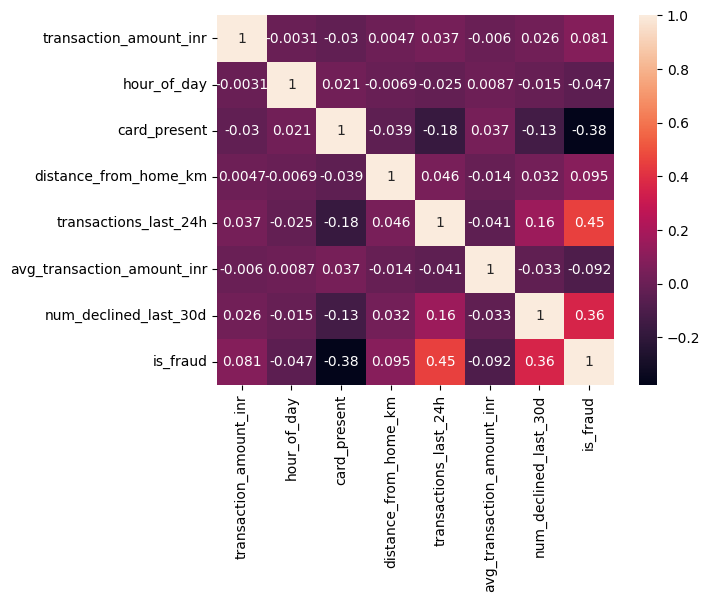

In [24]:
# Exploratory Data Analysis
sns.heatmap(d,annot=True)

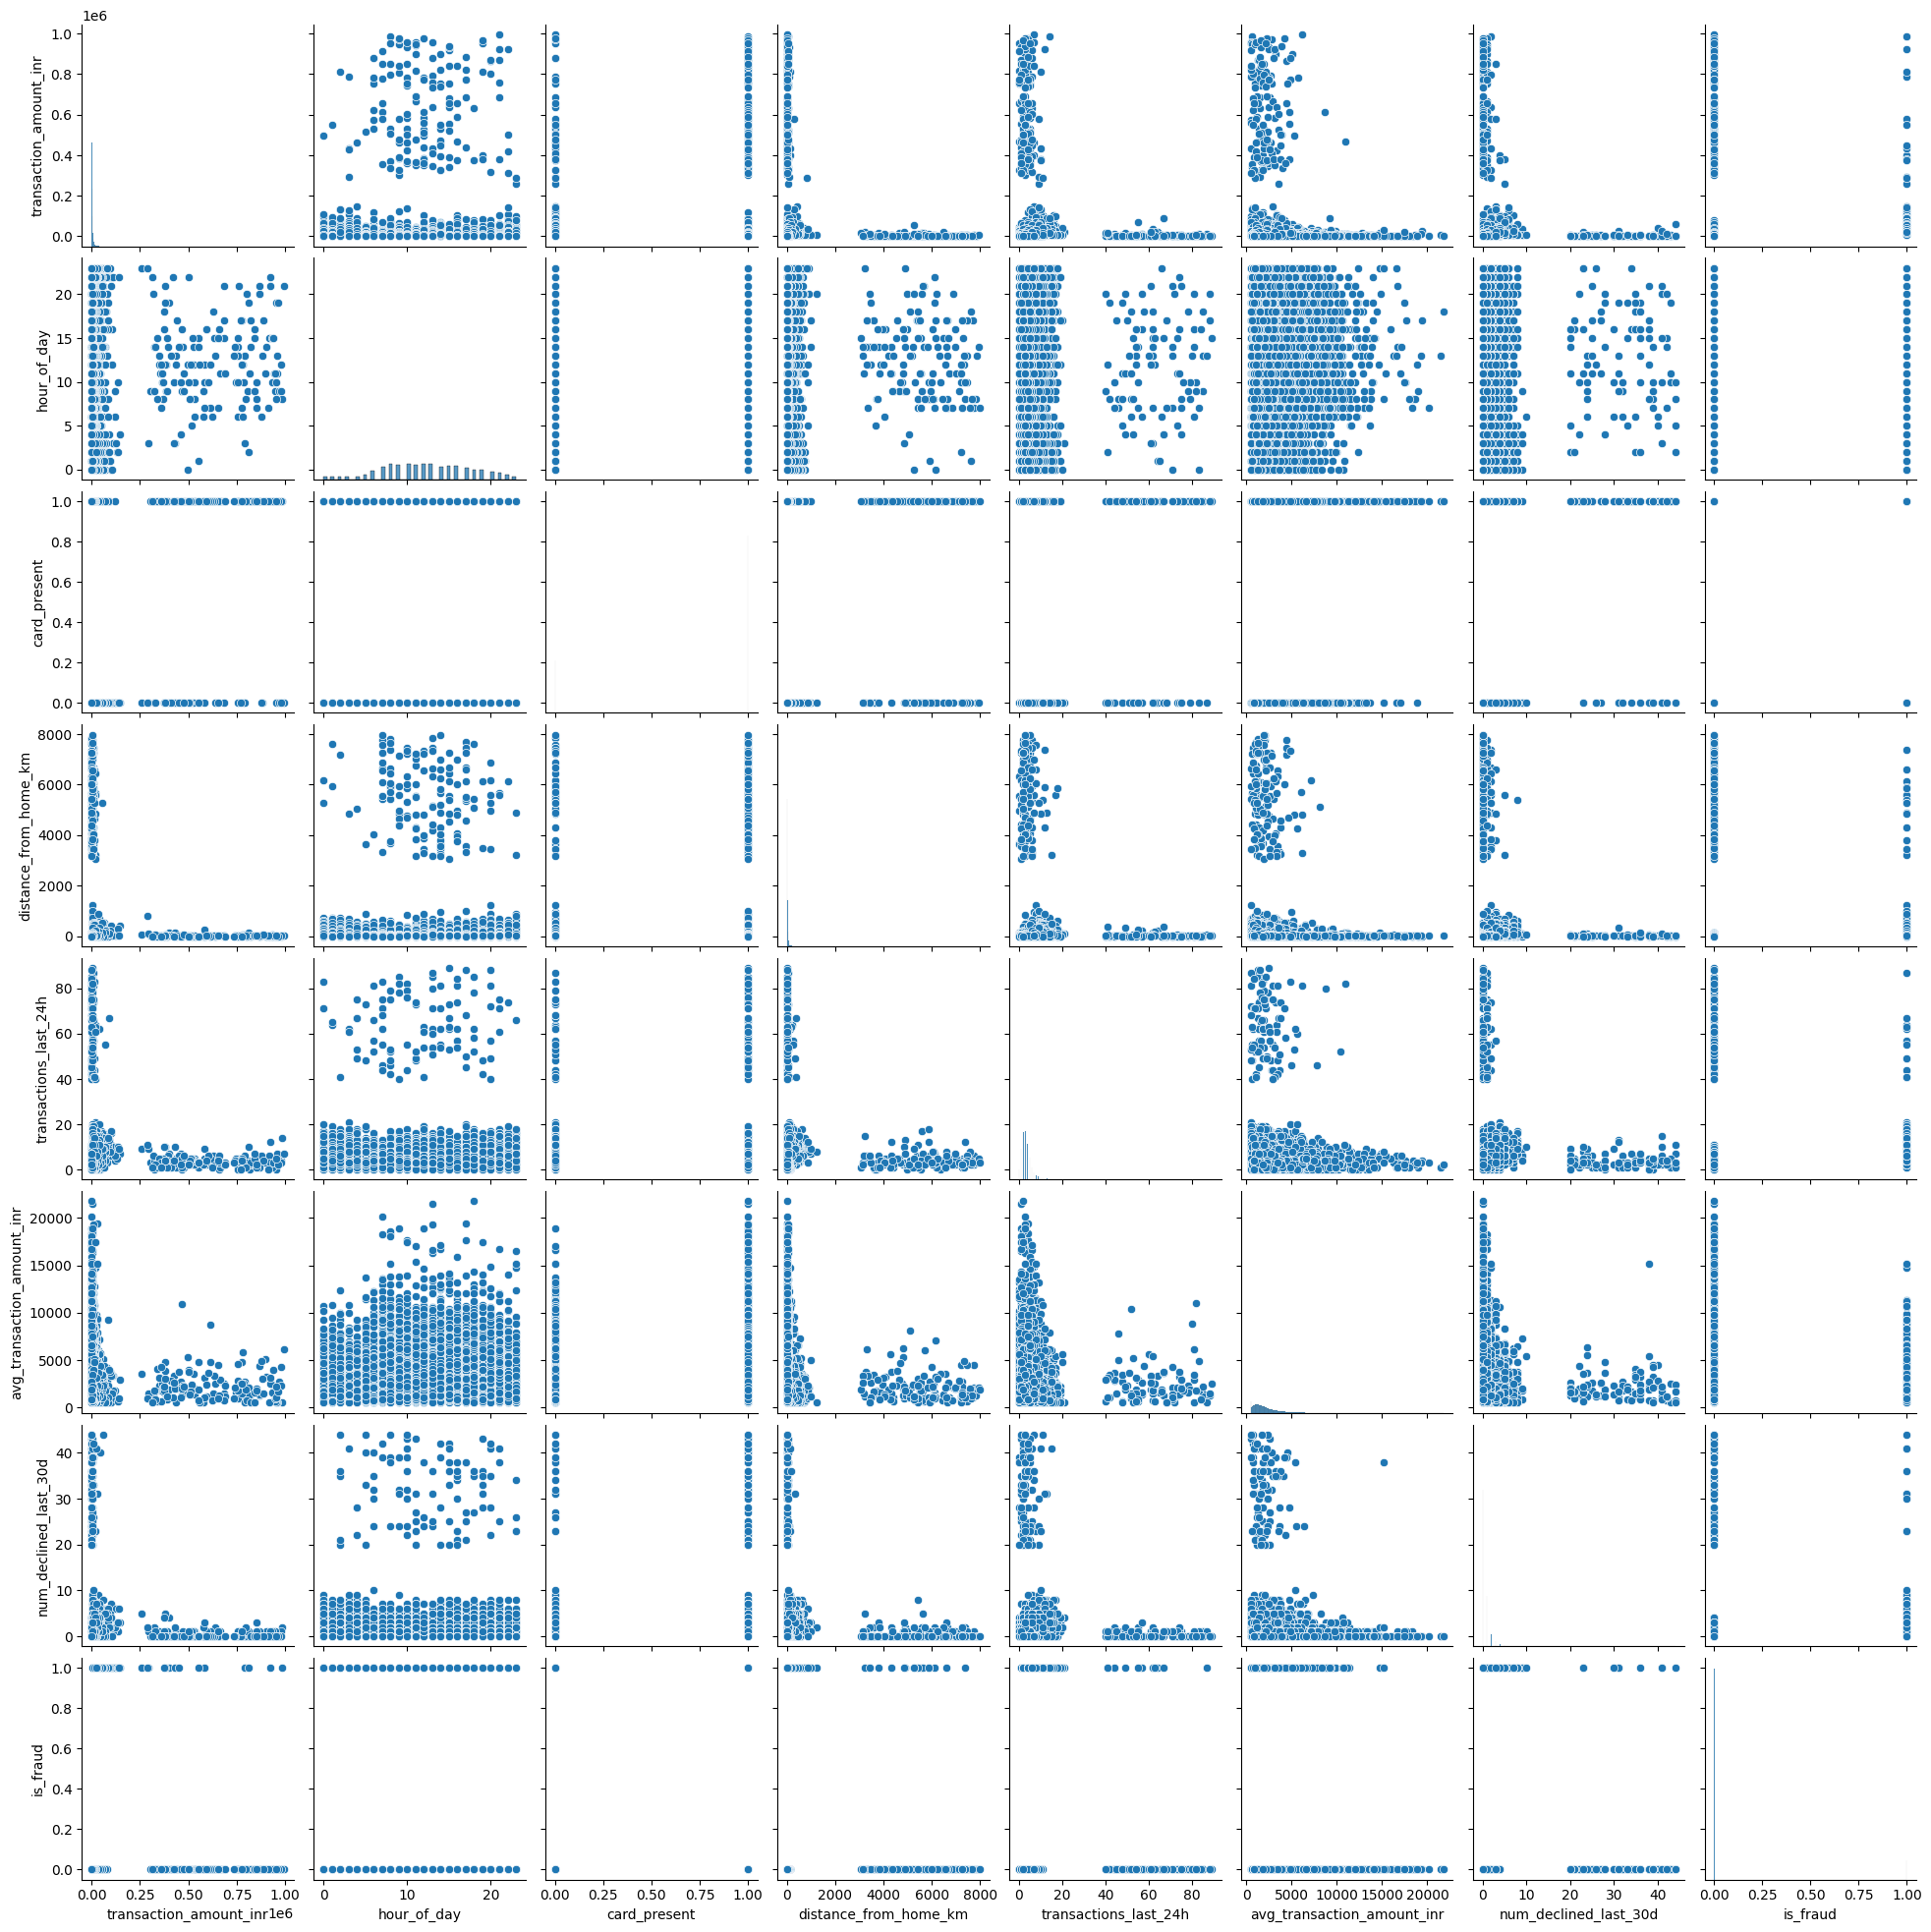

In [25]:
sns.pairplot(df)

(0.0, 100000.0)

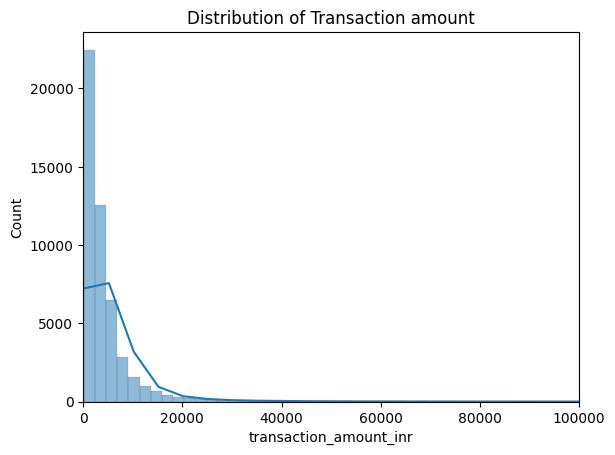

In [26]:
sns.histplot(df['transaction_amount_inr'],kde=True)
plt.title("Distribution of Transaction amount")
plt.xlim(0,100000)

<Figure size 2000x1000 with 0 Axes>

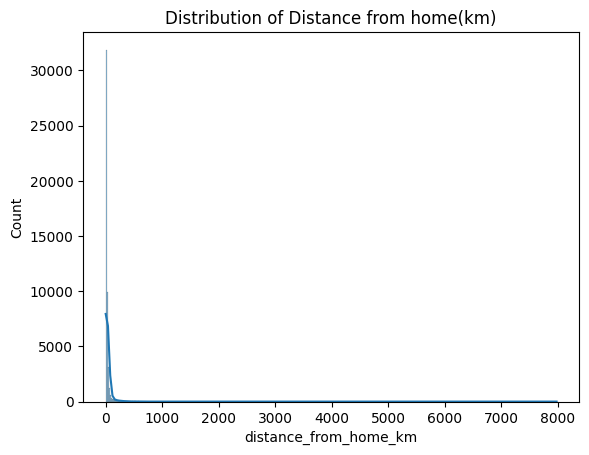

<Figure size 2000x1000 with 0 Axes>

In [27]:
sns.histplot(df['distance_from_home_km'],kde=True)
plt.title("Distribution of Distance from home(km)")
plt.figure(figsize=(20,10))

Text(0.5, 1.0, 'Distribution of average transaction amount')

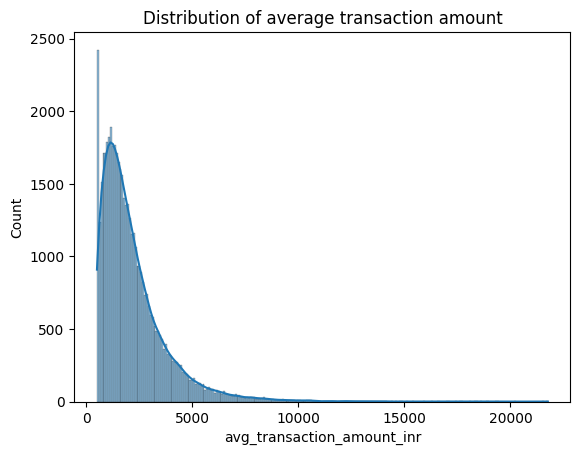

In [28]:
sns.histplot(df['avg_transaction_amount_inr'],kde=True)
plt.title("Distribution of average transaction amount")

Text(0.5, 1.0, 'Distribution of no of times declined')

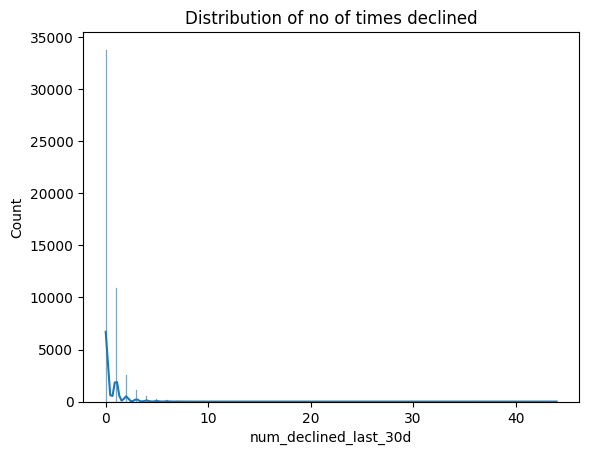

In [29]:
sns.histplot(df['num_declined_last_30d'],kde=True)
plt.title("Distribution of no of times declined")

hour_of_day


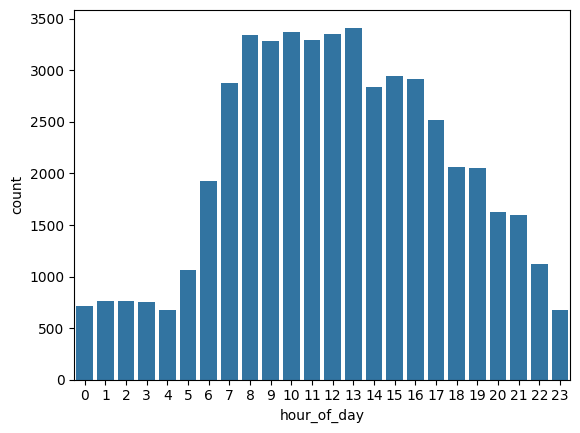

merchant_category


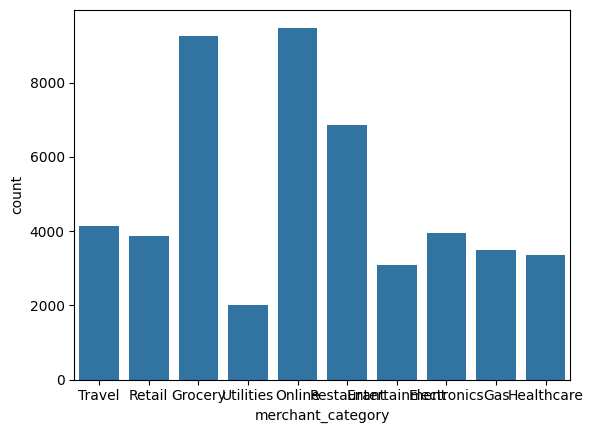

card_type


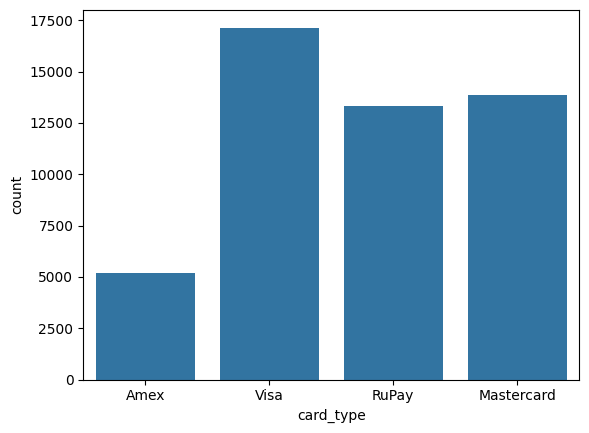

card_present


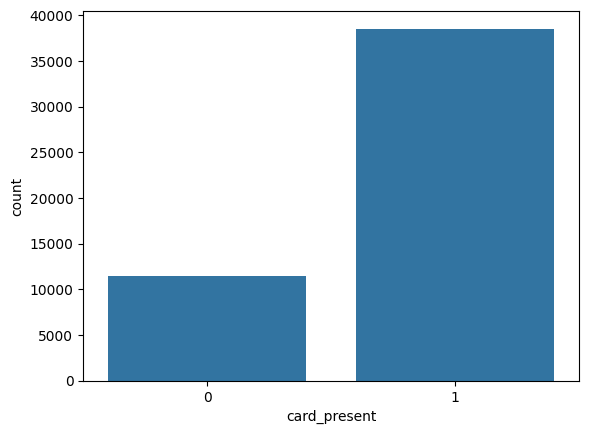

transactions_last_24h


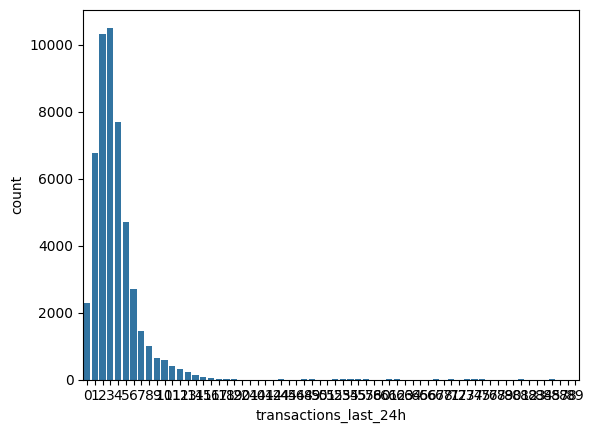

is_fraud


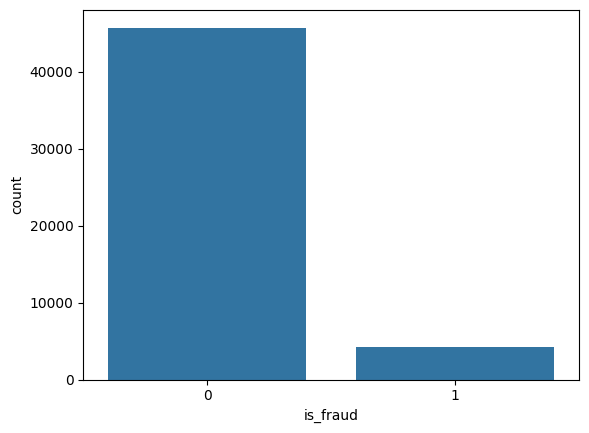

In [30]:
a=['hour_of_day','merchant_category','card_type','card_present','transactions_last_24h','is_fraud']
for i in a:
    print(i)
    sns.countplot(x=df[i])
    plt.show()

<Axes: xlabel='transaction_amount_inr'>

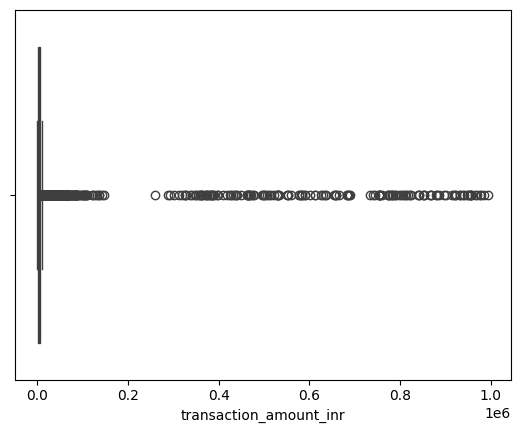

In [31]:
sns.boxplot(x='transaction_amount_inr',data=df)

<Axes: xlabel='hour_of_day'>

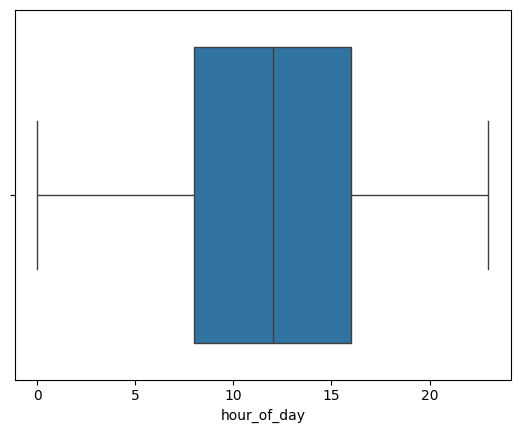

In [32]:
sns.boxplot(x='hour_of_day',data=df)

<Axes: xlabel='distance_from_home_km'>

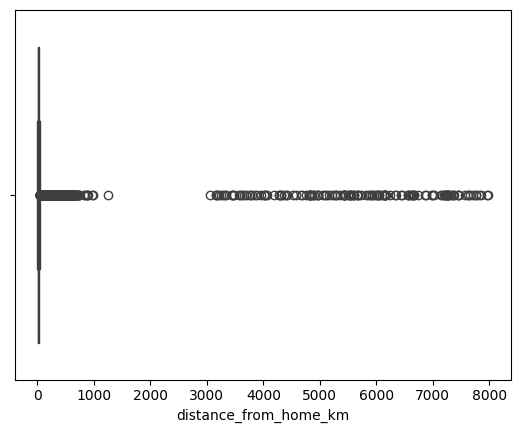

In [33]:
sns.boxplot(x='distance_from_home_km',data=df)

<Axes: xlabel='transactions_last_24h'>

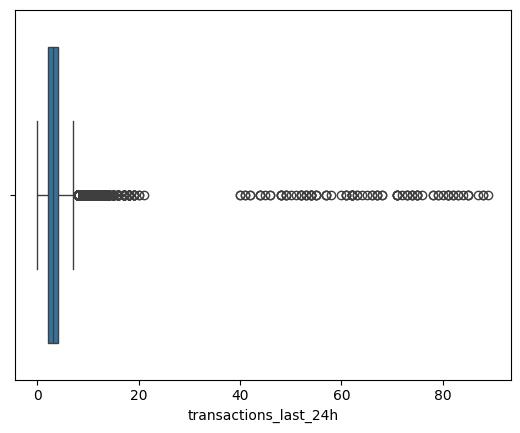

In [34]:
sns.boxplot(x='transactions_last_24h',data=df)

<Axes: xlabel='avg_transaction_amount_inr'>

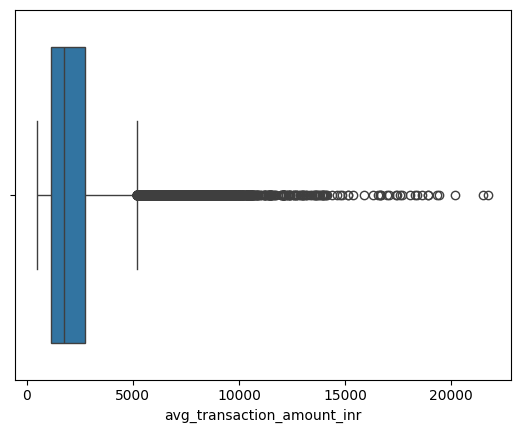

In [35]:
sns.boxplot(x='avg_transaction_amount_inr',data=df)

<Axes: xlabel='num_declined_last_30d'>

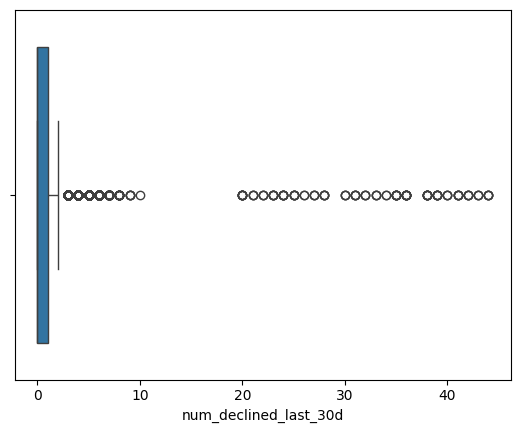

In [36]:
sns.boxplot(x='num_declined_last_30d',data=df)

# Preprocessing

## Filling missing values

In [37]:
df['transaction_amount_inr'].fillna(df['transaction_amount_inr'].median(),inplace=True)

In [38]:
df['merchant_category'].fillna(df['merchant_category'].mode()[0],inplace=True)

In [39]:
df['card_type'].fillna(df['card_type'].mode()[0],inplace=True)

In [40]:
df['distance_from_home_km'].fillna(df['distance_from_home_km'].median(),inplace=True) 

In [41]:
df['avg_transaction_amount_inr'].fillna(df['avg_transaction_amount_inr'].median(),inplace=True)

In [42]:
df['num_declined_last_30d'].fillna(df['num_declined_last_30d'].median(),inplace=True)

In [43]:
df.isna().sum()

transaction_amount_inr        0
hour_of_day                   0
merchant_category             0
card_type                     0
card_present                  0
distance_from_home_km         0
transactions_last_24h         0
avg_transaction_amount_inr    0
num_declined_last_30d         0
is_fraud                      0
dtype: int64

## Handling Outliers (IQR)

In [44]:
Q1=df['transaction_amount_inr'].quantile(0.25)
Q3=df['transaction_amount_inr'].quantile(0.75)
Q1,Q3

(np.float64(1473.0674999999999), np.float64(5007.4325))

In [45]:
IQR=Q3-Q1
IQR

np.float64(3534.365)

In [46]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit

(np.float64(-3828.4799999999996), np.float64(10308.98))

In [47]:
df.loc[(df['transaction_amount_inr']>upper_limit) | (df['transaction_amount_inr']<lower_limit)]

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
15,10507.32,19,Travel,Mastercard,1,24.94,7,2656.64,0.0,0
36,12505.20,17,Entertainment,Visa,0,160.66,8,3949.76,1.0,1
40,10416.25,16,Retail,Amex,0,5.16,5,1023.87,0.0,0
47,901152.90,14,Retail,Amex,1,0.18,3,3210.10,1.0,0
49,10313.29,9,Travel,RuPay,1,34.65,5,3751.42,1.0,0
...,...,...,...,...,...,...,...,...,...,...
49947,17162.91,20,Entertainment,RuPay,1,68.54,8,5120.50,0.0,1
49961,15174.43,8,Restaurant,Mastercard,1,0.86,1,4847.10,1.0,0
49985,11391.03,14,Electronics,Visa,1,10.81,2,3922.22,0.0,0
49990,22769.77,2,Utilities,Visa,0,8.43,6,3100.36,3.0,1


In [48]:
new_df= df.copy()
new_df.loc[(new_df['transaction_amount_inr']>upper_limit),'transaction_amount_inr']=upper_limit
new_df.loc[(new_df['transaction_amount_inr']<lower_limit),'transaction_amount_inr']=lower_limit

<Axes: ylabel='transaction_amount_inr'>

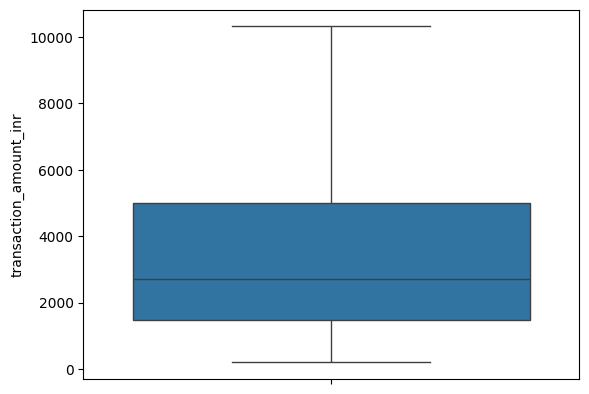

In [49]:
sns.boxplot(new_df['transaction_amount_inr'])

In [50]:
Q1=df['distance_from_home_km'].quantile(0.25)
Q3=df['distance_from_home_km'].quantile(0.75)
Q1,Q3

(np.float64(4.88), np.float64(24.13))

In [51]:
IQR=Q3-Q1
IQR

np.float64(19.25)

In [52]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit

(np.float64(-23.995), np.float64(53.004999999999995))

In [53]:
df.loc[(df['distance_from_home_km']>upper_limit) | (df['distance_from_home_km']<lower_limit)]

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
4,6914.66,13,Online,Visa,1,56.09,2,12672.62,0.0,0
7,8150.05,7,Online,Visa,0,59.60,12,8360.08,2.0,1
36,12505.20,17,Entertainment,Visa,0,160.66,8,3949.76,1.0,1
52,1562.49,9,Gas,Amex,1,69.48,2,500.00,2.0,0
55,5000.00,12,Electronics,Amex,0,93.08,7,5902.29,2.0,1
...,...,...,...,...,...,...,...,...,...,...
49906,3462.18,11,Grocery,Visa,1,3854.33,1,865.21,2.0,0
49917,3081.93,12,Restaurant,RuPay,1,91.06,3,1751.41,0.0,0
49947,17162.91,20,Entertainment,RuPay,1,68.54,8,5120.50,0.0,1
49952,866.13,9,Restaurant,Mastercard,1,4372.87,4,2292.30,1.0,0


In [54]:
new_df.loc[(new_df['distance_from_home_km']>upper_limit),'distance_from_home_km']=upper_limit
new_df.loc[(new_df['distance_from_home_km']<lower_limit),'distance_from_home_km']=lower_limit

<Axes: ylabel='distance_from_home_km'>

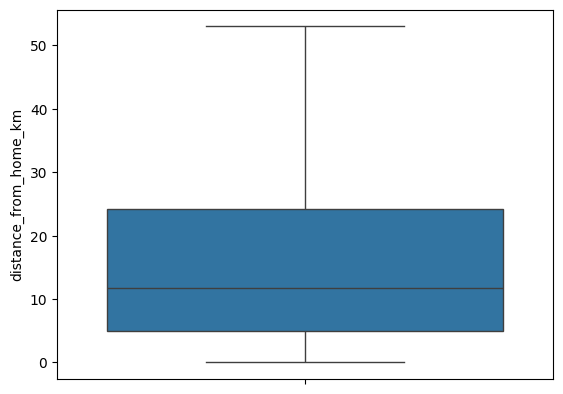

In [55]:
sns.boxplot(new_df['distance_from_home_km'])

In [56]:
Q1=df['transactions_last_24h'].quantile(0.25)
Q3=df['transactions_last_24h'].quantile(0.75)
Q1,Q3

(np.float64(2.0), np.float64(4.0))

In [57]:
IQR=Q3-Q1
IQR

np.float64(2.0)

In [58]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit

(np.float64(-1.0), np.float64(7.0))

In [59]:
df.loc[(df['transactions_last_24h']>upper_limit) | (df['transactions_last_24h']<lower_limit)]

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
7,8150.05,7,Online,Visa,0,59.60,12,8360.08,2.0,1
18,3176.57,14,Restaurant,Mastercard,1,9.47,55,2902.83,2.0,0
36,12505.20,17,Entertainment,Visa,0,160.66,8,3949.76,1.0,1
57,13013.20,5,Retail,RuPay,1,124.91,10,762.89,4.0,1
69,12333.11,12,Travel,RuPay,0,96.27,9,1354.65,2.0,1
...,...,...,...,...,...,...,...,...,...,...
49876,1696.07,15,Grocery,Visa,0,1.86,8,1072.86,2.0,0
49882,16979.12,23,Travel,Amex,0,96.98,14,790.83,5.0,1
49903,16097.40,13,Gas,RuPay,0,61.19,11,1907.11,1.0,1
49930,6972.88,6,Utilities,Visa,0,3.32,11,956.28,2.0,1


In [60]:
new_df.loc[(new_df['transactions_last_24h']>upper_limit),'transactions_last_24h']=upper_limit
new_df.loc[(new_df['transactions_last_24h']<lower_limit),'transactions_last_24h']=lower_limit

<Axes: ylabel='transactions_last_24h'>

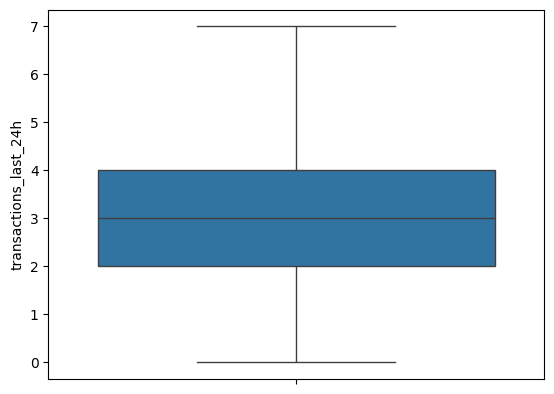

In [61]:
sns.boxplot(new_df['transactions_last_24h'])

In [62]:
Q1=df['avg_transaction_amount_inr'].quantile(0.25)
Q3=df['avg_transaction_amount_inr'].quantile(0.75)
Q1,Q3

(np.float64(1135.9524999999999), np.float64(2723.73))

In [63]:
IQR=Q3-Q1
IQR

np.float64(1587.7775000000001)

In [64]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit

(np.float64(-1245.7137500000003), np.float64(5105.39625))

In [65]:
df.loc[(df['avg_transaction_amount_inr']>upper_limit) | (df['avg_transaction_amount_inr']<lower_limit)]

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
4,6914.66,13,Online,Visa,1,56.09,2,12672.62,0.0,0
7,8150.05,7,Online,Visa,0,59.60,12,8360.08,2.0,1
31,4738.79,11,Travel,Mastercard,1,1.57,3,10121.74,2.0,0
53,663.73,3,Gas,Mastercard,1,4.39,4,6044.23,0.0,0
55,5000.00,12,Electronics,Amex,0,93.08,7,5902.29,2.0,1
...,...,...,...,...,...,...,...,...,...,...
49908,1771.21,13,Restaurant,Mastercard,0,7.56,4,8660.29,0.0,0
49947,17162.91,20,Entertainment,RuPay,1,68.54,8,5120.50,0.0,1
49975,616.74,7,Retail,Mastercard,0,11.52,4,6294.35,0.0,0
49978,773.99,0,Online,Mastercard,1,14.65,5,6266.02,0.0,0


In [66]:
new_df.loc[(new_df['avg_transaction_amount_inr']>upper_limit),'avg_transaction_amount_inr']=upper_limit
new_df.loc[(new_df['avg_transaction_amount_inr']<lower_limit),'avg_transaction_amount_inr']=lower_limit

<Axes: ylabel='avg_transaction_amount_inr'>

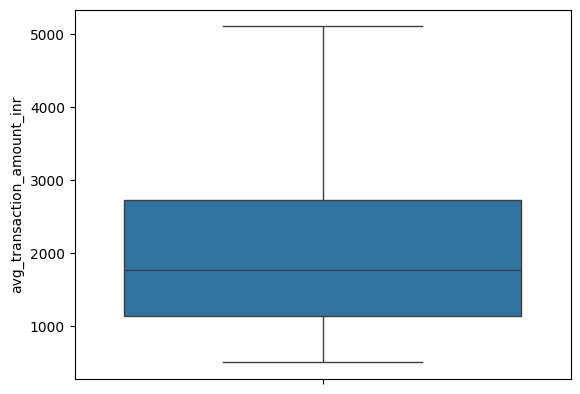

In [67]:
sns.boxplot(new_df['avg_transaction_amount_inr'])

In [68]:
Q1=df['num_declined_last_30d'].quantile(0.25)
Q3=df['num_declined_last_30d'].quantile(0.75)
Q1,Q3

(np.float64(0.0), np.float64(1.0))

In [69]:
IQR=Q3-Q1
IQR

np.float64(1.0)

In [70]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit

(np.float64(-1.5), np.float64(2.5))

In [71]:
df.loc[(df['num_declined_last_30d']>upper_limit) | (df['num_declined_last_30d']<lower_limit)]

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
2,923.78,20,Grocery,RuPay,1,4.88,5,4115.96,35.0,0
57,13013.20,5,Retail,RuPay,1,124.91,10,762.89,4.0,1
75,5876.14,1,Gas,Mastercard,0,298.99,9,1122.44,5.0,1
114,11328.77,18,Online,RuPay,0,137.35,6,986.53,5.0,1
115,11204.94,17,Online,Mastercard,0,91.69,8,873.78,5.0,1
...,...,...,...,...,...,...,...,...,...,...
49897,21809.16,22,Electronics,RuPay,0,201.08,6,1373.89,4.0,1
49902,7232.22,2,Entertainment,Mastercard,0,155.15,7,1845.18,36.0,1
49944,3756.78,10,Gas,RuPay,1,9.62,4,1119.49,3.0,0
49990,22769.77,2,Utilities,Visa,0,8.43,6,3100.36,3.0,1


In [72]:
new_df.loc[(new_df['num_declined_last_30d']>upper_limit),'num_declined_last_30d']=upper_limit
new_df.loc[(new_df['num_declined_last_30d']<lower_limit),'num_declined_last_30d']=lower_limit

<Axes: ylabel='num_declined_last_30d'>

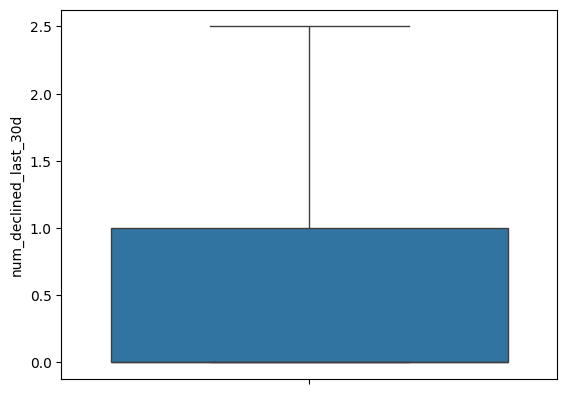

In [73]:
sns.boxplot(new_df['num_declined_last_30d'])

## Label Encoding

In [74]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
df['merchant_category']=le1.fit_transform(df['merchant_category'])
df

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
0,1738.38,15,8,Amex,0,42.33,1,2648.87,1.0,0
1,1450.18,14,7,Visa,1,3.09,3,1754.85,0.0,0
2,923.78,20,3,RuPay,1,4.88,5,4115.96,35.0,0
3,885.04,12,9,Mastercard,1,6.35,6,665.16,1.0,0
4,6914.66,13,5,Visa,1,56.09,2,12672.62,0.0,0
...,...,...,...,...,...,...,...,...,...,...
49995,1410.70,19,9,Mastercard,0,14.64,4,911.48,0.0,0
49996,1368.41,16,9,RuPay,1,24.89,1,2358.95,0.0,0
49997,1652.39,11,1,Mastercard,1,45.06,7,2688.45,0.0,0
49998,2900.05,19,3,RuPay,1,15.60,1,2162.72,1.0,0


In [75]:
le2=LabelEncoder()
df['card_type']=le2.fit_transform(df['card_type'])
df

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d,is_fraud
0,1738.38,15,8,0,0,42.33,1,2648.87,1.0,0
1,1450.18,14,7,3,1,3.09,3,1754.85,0.0,0
2,923.78,20,3,2,1,4.88,5,4115.96,35.0,0
3,885.04,12,9,1,1,6.35,6,665.16,1.0,0
4,6914.66,13,5,3,1,56.09,2,12672.62,0.0,0
...,...,...,...,...,...,...,...,...,...,...
49995,1410.70,19,9,1,0,14.64,4,911.48,0.0,0
49996,1368.41,16,9,2,1,24.89,1,2358.95,0.0,0
49997,1652.39,11,1,1,1,45.06,7,2688.45,0.0,0
49998,2900.05,19,3,2,1,15.60,1,2162.72,1.0,0


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   transaction_amount_inr      50000 non-null  float64
 1   hour_of_day                 50000 non-null  int64  
 2   merchant_category           50000 non-null  int64  
 3   card_type                   50000 non-null  int64  
 4   card_present                50000 non-null  int64  
 5   distance_from_home_km       50000 non-null  float64
 6   transactions_last_24h       50000 non-null  int64  
 7   avg_transaction_amount_inr  50000 non-null  float64
 8   num_declined_last_30d       50000 non-null  float64
 9   is_fraud                    50000 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 3.8 MB


## Data Splitting

In [77]:
x=df.drop('is_fraud',axis=1)
y=df['is_fraud']
x

,transaction_amount_inr,hour_of_day,merchant_category,card_type,card_present,distance_from_home_km,transactions_last_24h,avg_transaction_amount_inr,num_declined_last_30d
0,1738.38,15,8,0,0,42.33,1,2648.87,1.0
1,1450.18,14,7,3,1,3.09,3,1754.85,0.0
2,923.78,20,3,2,1,4.88,5,4115.96,35.0
3,885.04,12,9,1,1,6.35,6,665.16,1.0
4,6914.66,13,5,3,1,56.09,2,12672.62,0.0
...,...,...,...,...,...,...,...,...,...
49995,1410.70,19,9,1,0,14.64,4,911.48,0.0
49996,1368.41,16,9,2,1,24.89,1,2358.95,0.0
49997,1652.39,11,1,1,1,45.06,7,2688.45,0.0
49998,2900.05,19,3,2,1,15.60,1,2162.72,1.0


## Train-Test Split

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

## Scaling

In [80]:
from sklearn.preprocessing import StandardScaler
sd=StandardScaler()
x_train=sd.fit_transform(x_train)
x_test=sd.transform(x_test)
x_train

array([[-0.07632763, -0.981991  ,  0.65413311, ..., -0.44228635,
        -0.18545498, -0.31542424],
       [ 0.02382495,  0.51809073,  1.89081321, ...,  1.19396433,
        -0.82877509,  0.25923863],
       [-0.14804701,  0.89311116,  0.24190641, ..., -0.44228635,
        -0.51550064, -0.31542424],
       ...,
       [-0.13519721, -0.23195014, -0.1703203 , ...,  0.92125589,
         1.2610521 ,  0.25923863],
       [-0.13607479,  0.14307029,  0.24190641, ..., -0.1695779 ,
        -0.69433842, -0.31542424],
       [ 0.19034443,  0.33058051,  0.24190641, ..., -0.1695779 ,
         1.58001655, -0.31542424]], shape=(35000, 9))

# INITIAL PERFORMANCE

## Logistic Regression 

In [81]:
from sklearn.linear_model import LogisticRegression
log=LogisticRegression()
log.fit(x_train,y_train)
y_pred=log.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(15000,))

In [82]:
print('Testing score:',log.score(x_test,y_test))
print('Training score:',log.score(x_train,y_train))

Testing score: 0.9669333333333333
Training score: 0.966


In [83]:
# Model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
log_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',log_acc)

accuracy score: 0.9669333333333333


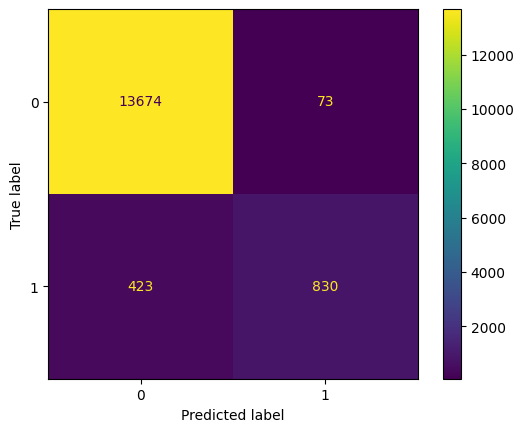

In [84]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [85]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13747
           1       0.92      0.66      0.77      1253

    accuracy                           0.97     15000
   macro avg       0.94      0.83      0.88     15000
weighted avg       0.97      0.97      0.96     15000



## KNeighborsClassifier (KNN)

In [86]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(15000,))

In [87]:
print('Testing score:',knn.score(x_test,y_test))
print('Training score:',knn.score(x_train,y_train))

Testing score: 0.9854666666666667
Training score: 0.9908571428571429


In [88]:
knn_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',knn_acc)

accuracy score: 0.9854666666666667


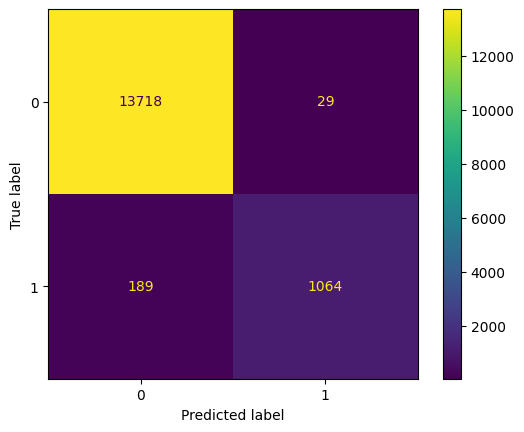

In [89]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [90]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     13747
           1       0.97      0.85      0.91      1253

    accuracy                           0.99     15000
   macro avg       0.98      0.92      0.95     15000
weighted avg       0.99      0.99      0.99     15000



## Support Vector Classifier (SVC)

In [91]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(15000,))

In [92]:
print('Testing score:',svm.score(x_test,y_test))
print('Training score:',svm.score(x_train,y_train))

Testing score: 0.9921333333333333
Training score: 0.9936857142857143


In [93]:
svm_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',svm_acc)

accuracy score: 0.9921333333333333


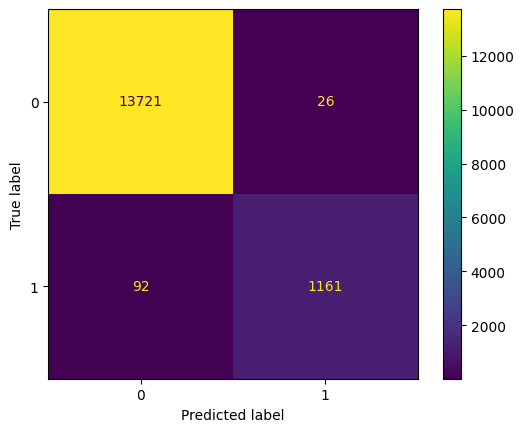

In [94]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [95]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     13747
           1       0.98      0.93      0.95      1253

    accuracy                           0.99     15000
   macro avg       0.99      0.96      0.97     15000
weighted avg       0.99      0.99      0.99     15000



## Naive Bayes (GaussianNB)

In [96]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(15000,))

In [97]:
print('Testing score:',nb.score(x_test,y_test))
print('Training score:',nb.score(x_train,y_train))

Testing score: 0.9726
Training score: 0.9726


In [98]:
nb_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',nb_acc)

accuracy score: 0.9726


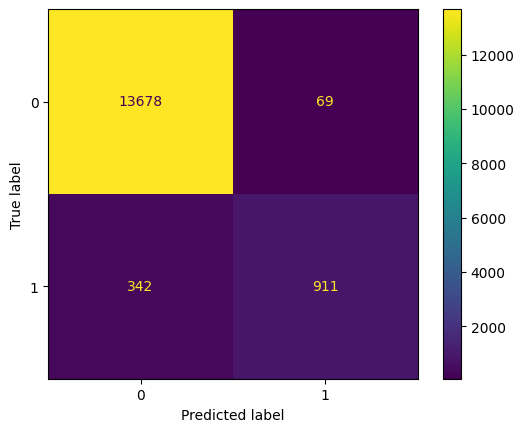

In [99]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [100]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     13747
           1       0.93      0.73      0.82      1253

    accuracy                           0.97     15000
   macro avg       0.95      0.86      0.90     15000
weighted avg       0.97      0.97      0.97     15000



## Decision Tree Classifier

In [101]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier()
tree.fit(x_train,y_train)
y_pred=tree.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(15000,))

In [102]:
print('Testing score:',tree.score(x_test,y_test))
print('Training score:',tree.score(x_train,y_train))

Testing score: 0.9921333333333333
Training score: 1.0


In [103]:
tree_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',tree_acc)

accuracy score: 0.9921333333333333


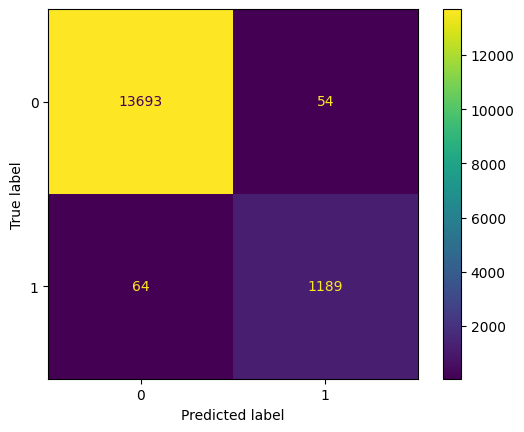

In [104]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [105]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13747
           1       0.96      0.95      0.95      1253

    accuracy                           0.99     15000
   macro avg       0.98      0.97      0.97     15000
weighted avg       0.99      0.99      0.99     15000



## Random Forest

In [106]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)     
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(15000,))

In [107]:
print('Testing score:',model.score(x_test,y_test))
print('Training score:',model.score(x_train,y_train))

Testing score: 0.9955333333333334
Training score: 1.0


In [108]:
model_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',model_acc)

accuracy score: 0.9955333333333334


Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5CE30CDD0>


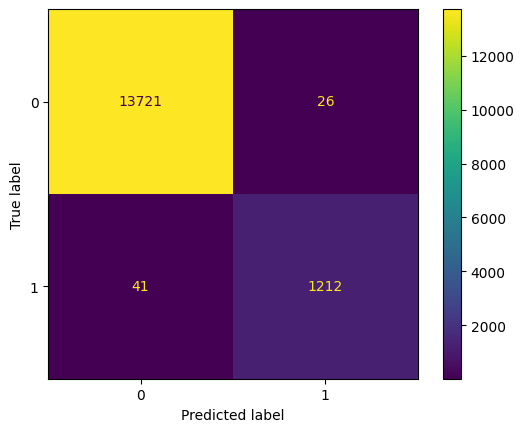

In [109]:
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [110]:
print('Classification report:',classification_report(y_test,y_pred))

Classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13747
           1       0.98      0.97      0.97      1253

    accuracy                           1.00     15000
   macro avg       0.99      0.98      0.99     15000
weighted avg       1.00      1.00      1.00     15000



## Ada Boost Classifier

In [111]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(n_estimators=50,estimator=None,learning_rate=0.3,random_state=42)
ada.fit(x_train,y_train)
y_pred=ada.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(15000,))

In [112]:
print('Testing score:',ada.score(x_test,y_test))
print('Training score:',ada.score(x_train,y_train))

Testing score: 0.9930666666666667
Training score: 0.9940571428571429


In [113]:
ada_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',ada_acc)

accuracy score: 0.9930666666666667


Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5CE68E9C0>


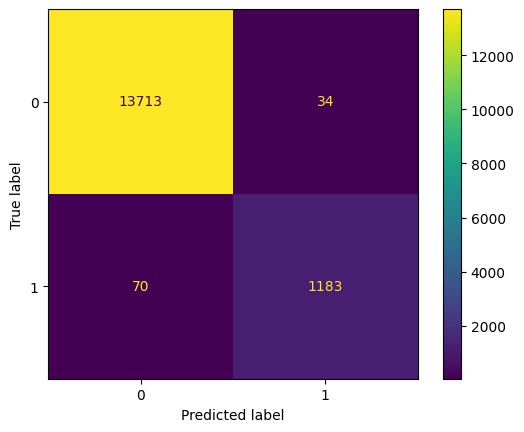

In [114]:
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [115]:
print('Classification report:',classification_report(y_test,y_pred))

Classification report:               precision    recall  f1-score   support

           0       0.99      1.00      1.00     13747
           1       0.97      0.94      0.96      1253

    accuracy                           0.99     15000
   macro avg       0.98      0.97      0.98     15000
weighted avg       0.99      0.99      0.99     15000



## Gradient Boost Classifier

In [116]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier(n_estimators=50,learning_rate=0.05,random_state=42)
gbc.fit(x_train,y_train)
y_pred=gbc.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(15000,))

In [117]:
print('Testing score:',gbc.score(x_test,y_test))
print('Training score:',gbc.score(x_train,y_train))

Testing score: 0.9910666666666667
Training score: 0.9911142857142857


In [118]:
gbc_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',gbc_acc)

accuracy score: 0.9910666666666667


Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5DCD589E0>


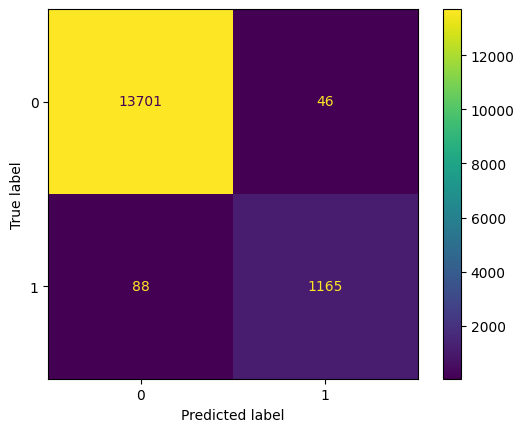

In [119]:
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [120]:
print('Classification report:',classification_report(y_test,y_pred))

Classification report:               precision    recall  f1-score   support

           0       0.99      1.00      1.00     13747
           1       0.96      0.93      0.95      1253

    accuracy                           0.99     15000
   macro avg       0.98      0.96      0.97     15000
weighted avg       0.99      0.99      0.99     15000



## XGB Classifier

In [121]:
from xgboost import XGBClassifier
xgb= XGBClassifier()
xgb.fit(x_train, y_train)
y_pred=xgb.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(15000,))

In [122]:
print('Testing score:',xgb.score(x_test,y_test))
print('Training score:',xgb.score(x_train,y_train))

Testing score: 0.9953333333333333
Training score: 1.0


In [123]:
xgb_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',xgb_acc)

accuracy score: 0.9953333333333333


Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5DD31C050>


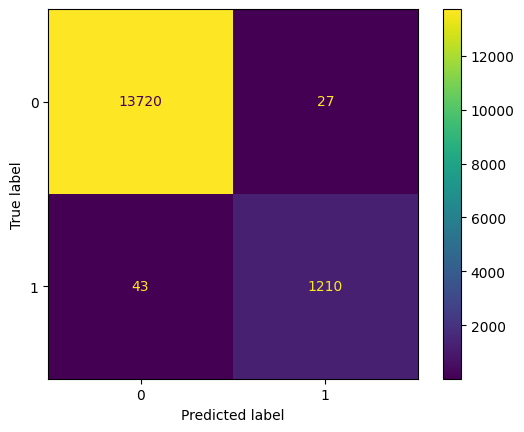

In [124]:
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [125]:
print('Classification report:',classification_report(y_test,y_pred))

Classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13747
           1       0.98      0.97      0.97      1253

    accuracy                           1.00     15000
   macro avg       0.99      0.98      0.98     15000
weighted avg       1.00      1.00      1.00     15000



## INITIAL ACCURACY

In [126]:
tb=pd.DataFrame()
tb['Model']=pd.Series(['LogisticRegression','KNeighborsClassifier','SVC','GaussianNB','DecisionTreeClassifier','RandomForestClassifier','AdaBoostClassifier','GradientBoostingClassifier','XGBClassifier'])
tb['Accuracy']=pd.Series([log_acc,knn_acc,svm_acc,nb_acc,tree_acc,model_acc,ada_acc,gbc_acc,xgb_acc])
tb.sort_values(by=['Accuracy'],ascending=False).reset_index(drop=True)

,Model,Accuracy
0,RandomForestClassifier,0.995533
1,XGBClassifier,0.995333
2,AdaBoostClassifier,0.993067
3,SVC,0.992133
4,DecisionTreeClassifier,0.992133
5,GradientBoostingClassifier,0.991067
6,KNeighborsClassifier,0.985467
7,GaussianNB,0.972600
8,LogisticRegression,0.966933


## OVERSAMPLING

In [127]:
df['is_fraud'].value_counts()

is_fraud
0    45750
1     4250
Name: count, dtype: int64

In [128]:
!pip install -U scikit-learn imbalanced-learn
from imblearn.over_sampling import SMOTE
over=SMOTE(random_state=2)
x_ov,y_ov = over.fit_resample(x,y)

In [129]:
y_ov.value_counts()

is_fraud
0    45750
1    45750
Name: count, dtype: int64

In [130]:
x_train,x_test,y_train,y_test=train_test_split(x_ov,y_ov,test_size=0.3,random_state=42)

## Logistic Regression

In [131]:
log1=LogisticRegression()
log1.fit(x_ov,y_ov)
y_pred=log1.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 1, 1], shape=(27450,))

Testing score: 0.9306375227686703
Training score: 0.9317923497267759
Classification report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93     13746
           1       0.92      0.94      0.93     13704

    accuracy                           0.93     27450
   macro avg       0.93      0.93      0.93     27450
weighted avg       0.93      0.93      0.93     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5EB43DF50>


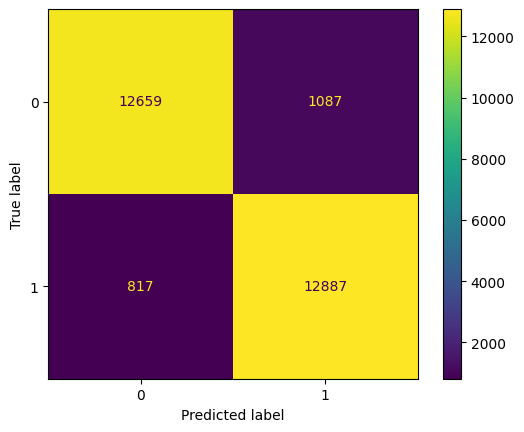

In [132]:
print('Testing score:',log1.score(x_test,y_test))
print('Training score:',log1.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [133]:
log1_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',log1_acc)

accuracy score: 0.9306375227686703


## KNeighborsClassifier (KNN)

In [134]:
knn1=KNeighborsClassifier(n_neighbors=3)
knn1.fit(x_ov,y_ov)
y_pred=knn1.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(27450,))

Testing score: 0.9779963570127505
Training score: 0.9779344262295082
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98     13746
           1       0.96      0.99      0.98     13704

    accuracy                           0.98     27450
   macro avg       0.98      0.98      0.98     27450
weighted avg       0.98      0.98      0.98     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5EB373B60>


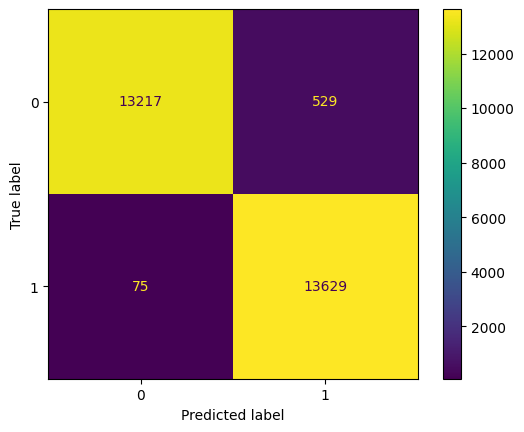

In [135]:
print('Testing score:',knn1.score(x_test,y_test))
print('Training score:',knn1.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [136]:
knn1_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',knn1_acc)

accuracy score: 0.9779963570127505


## Support Vector Classifier (SVC)

In [ ]:
svm1=SVC()
svm1.fit(x_ov,y_ov)
y_pred=svm1.predict(x_test)
y_pred

In [ ]:
print('Testing score:',svm1.score(x_test,y_test))
print('Training score:',svm1.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [ ]:
svm1_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',svm1_acc)

## Naive Bayes (GaussianNB) 

In [140]:
nb1=GaussianNB()
nb1.fit(x_ov,y_ov)
y_pred=nb1.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 1, 0], shape=(27450,))

Testing score: 0.9602185792349727
Training score: 0.9597377049180328
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96     13746
           1       0.97      0.95      0.96     13704

    accuracy                           0.96     27450
   macro avg       0.96      0.96      0.96     27450
weighted avg       0.96      0.96      0.96     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5EB373F20>


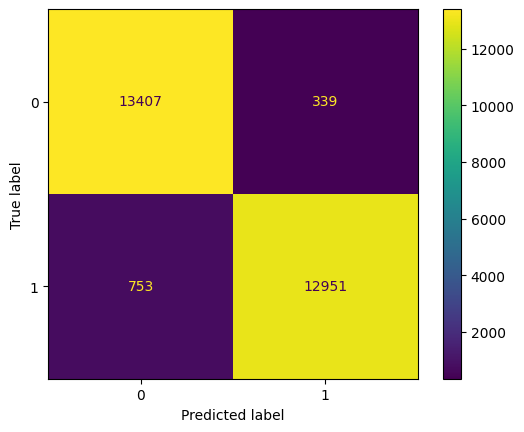

In [141]:
print('Testing score:',nb1.score(x_test,y_test))
print('Training score:',nb1.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [142]:
nb1_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',nb1_acc)

accuracy score: 0.9602185792349727


## Decision Tree Classifier

In [143]:
tree1=DecisionTreeClassifier()
tree1.fit(x_ov,y_ov)
y_pred=tree1.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(27450,))

Testing score: 1.0
Training score: 1.0
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13746
           1       1.00      1.00      1.00     13704

    accuracy                           1.00     27450
   macro avg       1.00      1.00      1.00     27450
weighted avg       1.00      1.00      1.00     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5EB525C50>


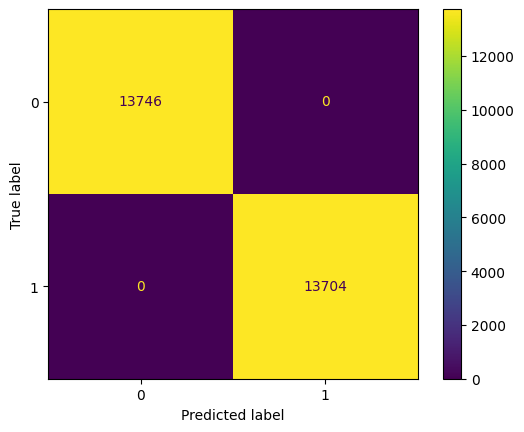

In [144]:
print('Testing score:',tree1.score(x_test,y_test))
print('Training score:',tree1.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [145]:
tree1_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',tree1_acc)

accuracy score: 1.0


## Random Forest

In [146]:
model1=RandomForestClassifier(n_estimators=100,random_state=42)
model1.fit(x_ov,y_ov)     
y_pred=model1.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(27450,))

Testing score: 1.0
Training score: 1.0
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13746
           1       1.00      1.00      1.00     13704

    accuracy                           1.00     27450
   macro avg       1.00      1.00      1.00     27450
weighted avg       1.00      1.00      1.00     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5E0352B30>


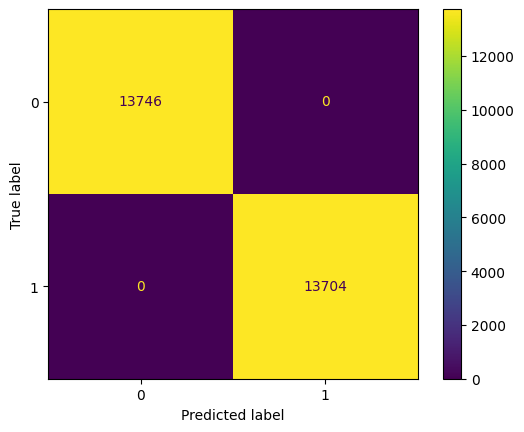

In [147]:
print('Testing score:',model1.score(x_test,y_test))
print('Training score:',model1.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [148]:
model1_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',model1_acc)

accuracy score: 1.0


## Ada Boost Classifier

In [149]:
ada1=AdaBoostClassifier(n_estimators=50,estimator=None,learning_rate=0.3,random_state=42)
ada1.fit(x_ov,y_ov)
y_pred=ada1.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(27450,))

Testing score: 0.9939890710382514
Training score: 0.9939890710382514
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     13746
           1       0.99      0.99      0.99     13704

    accuracy                           0.99     27450
   macro avg       0.99      0.99      0.99     27450
weighted avg       0.99      0.99      0.99     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5EB4B6680>


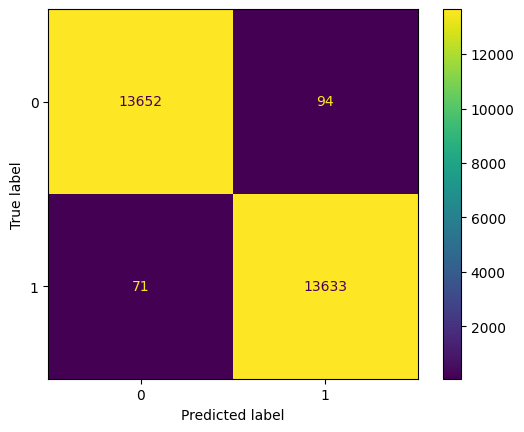

In [150]:
print('Testing score:',ada1.score(x_test,y_test))
print('Training score:',ada1.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [151]:
ada1_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',ada1_acc)

accuracy score: 0.9939890710382514


## Gradient Boost Classifier

In [152]:
gbc1=GradientBoostingClassifier(n_estimators=50,learning_rate=0.05,random_state=42)
gbc1.fit(x_ov,y_ov)
y_pred=gbc1.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(27450,))

Testing score: 0.9929326047358834
Training score: 0.9927213114754099
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     13746
           1       0.99      0.99      0.99     13704

    accuracy                           0.99     27450
   macro avg       0.99      0.99      0.99     27450
weighted avg       0.99      0.99      0.99     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5EB4DFB90>


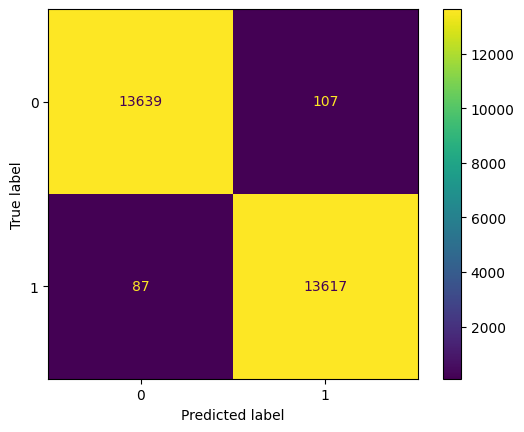

In [153]:
print('Testing score:',gbc1.score(x_test,y_test))
print('Training score:',gbc1.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [154]:
gbc1_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',gbc1_acc)

accuracy score: 0.9929326047358834


## XGB Classifier

In [155]:
xgb1= XGBClassifier()
xgb1.fit(x_ov, y_ov)
y_pred=xgb1.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(27450,))

Testing score: 0.9998907103825136
Training score: 0.9999672131147541
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13746
           1       1.00      1.00      1.00     13704

    accuracy                           1.00     27450
   macro avg       1.00      1.00      1.00     27450
weighted avg       1.00      1.00      1.00     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5EB4DE450>


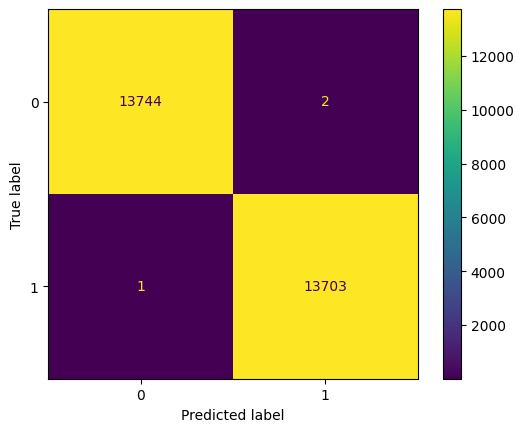

In [156]:
print('Testing score:',xgb1.score(x_test,y_test))
print('Training score:',xgb1.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [157]:
xgb1_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',xgb1_acc)

accuracy score: 0.9998907103825136


## ACCURACY AFTER OVERSAMPLING

In [ ]:
tbc=pd.DataFrame()
tbc['Model']=pd.Series(['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier','AdaBoostClassifier','GradientBoostingClassifier','XGBClassifier','KNeighborsClassifier','GaussianNB','SVC'])
tbc['Accuracy']=pd.Series([log_acc,knn_acc,svm_acc,nb_acc,tree_acc,model_acc,ada_acc,gbc_acc,xgb_acc])
tbc['Accuracy_oversampling']=pd.Series([log1_acc,knn1_acc,svm1_acc,nb1_acc,tree1_acc,model1_acc,ada1_acc,gbc1_acc,xgb1_acc])
tbc.sort_values(by=['Accuracy_oversampling'],ascending=False).reset_index(drop=True)

# HYPER PARAMETER TUNING

## Logistic Regression

In [159]:
from sklearn.model_selection import GridSearchCV
par={'C':[0.1,1,10],'penalty':['l1','l2']}
logt=GridSearchCV(log,par,cv=10,scoring='accuracy')
logt.fit(x_ov,y_ov)
print(logt.best_params_)

{'C': 0.1, 'penalty': 'l2'}


Testing score: 0.9305646630236795
Training score: 0.9318360655737705
Classification report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93     13746
           1       0.92      0.94      0.93     13704

    accuracy                           0.93     27450
   macro avg       0.93      0.93      0.93     27450
weighted avg       0.93      0.93      0.93     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5DD6DB5F0>


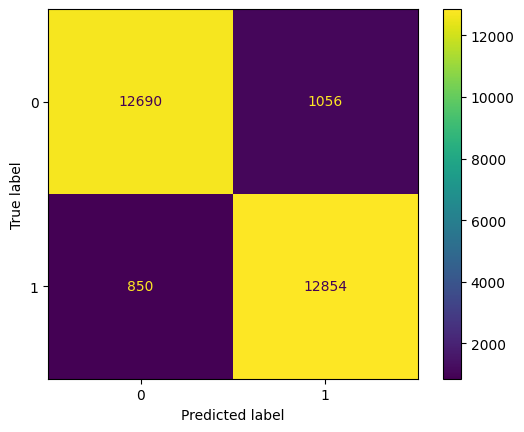

In [160]:
log2=LogisticRegression(C=0.1,penalty='l2')

log2.fit(x_ov,y_ov)
y_pred=log2.predict(x_test)
print('Testing score:',log2.score(x_test,y_test))
print('Training score:',log2.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [161]:
log2_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',log2_acc)

accuracy score: 0.9305646630236795


## KNeighborsClassifier (KNN)

In [162]:
par={'n_neighbors':[3,5,7,9],'weights':['uniform','distance']}
knt=GridSearchCV(knn,par,cv=10,scoring='accuracy')
knt.fit(x_ov,y_ov)
print(knt.best_params_) 

{'n_neighbors': 3, 'weights': 'distance'}


Testing score: 1.0
Training score: 1.0
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13746
           1       1.00      1.00      1.00     13704

    accuracy                           1.00     27450
   macro avg       1.00      1.00      1.00     27450
weighted avg       1.00      1.00      1.00     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5DD6D0100>


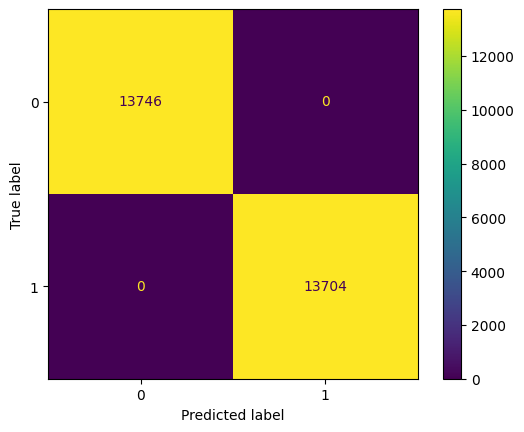

In [163]:
knn2=KNeighborsClassifier(n_neighbors=3,weights='distance') 

knn2.fit(x_ov,y_ov)
y_pred=knn2.predict(x_test)
print('Testing score:',knn2.score(x_test,y_test))
print('Training score:',knn2.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [164]:
knn2_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',knn2_acc)

accuracy score: 1.0


## Support Vector Classifier (SVC)

In [165]:
# par={'C':[0.1,1,10],'gamma':['scale','auto']}
# svcg=GridSearchCV(svm,par,cv=3,n_jobs=-1,scoring='accuracy')
# svcg.fit(x_ov,y_ov)
# print(svcg.best_params_)

In [166]:
# svm2=SVC(C=,,gamma='') 
# svm2.fit(x_ov,y_ov)
# y_pred=svm2.predict(x_test)
# print('Testing score:',svm2.score(x_test,y_test))
# print('Training score:',svm2.score(x_ov,y_ov))
# print('Classification report:\n',classification_report(y_test,y_pred))
# print('Confusion matrix:\n',confusion_matrix(y_test,y_pred))

In [167]:
# svm2_acc=accuracy_score(y_test,y_pred)
# print('accuracy score:',svm2_acc)

## Naive Bayes (GaussianNB) 

In [168]:
par={'var_smoothing':[1e-9,1e-8,1e-7,1e-6,1e-5,1e-4]}
nbt=GridSearchCV(nb,par,cv=5,scoring='accuracy')
nbt.fit(x_ov,y_ov)
print(nbt.best_params_)

{'var_smoothing': 1e-09}


Testing score: 0.9602185792349727
Training score: 0.9597377049180328
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96     13746
           1       0.97      0.95      0.96     13704

    accuracy                           0.96     27450
   macro avg       0.96      0.96      0.96     27450
weighted avg       0.96      0.96      0.96     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5E032F390>


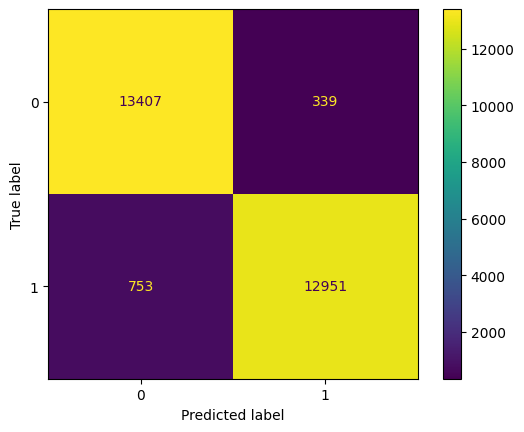

In [169]:
nb2=GaussianNB(var_smoothing=1e-09)

nb2.fit(x_ov,y_ov)
y_pred=nb2.predict(x_test)
print('Testing score:',nb2.score(x_test,y_test))
print('Training score:',nb2.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [170]:
nb2_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',nb2_acc)

accuracy score: 0.9602185792349727


## Decision Tree classifier

In [171]:
par={'max_depth':[3,5,10],'min_samples_split':[2,5,10]}
dtt=GridSearchCV(tree,par,cv=5,scoring='accuracy')
dtt.fit(x_ov,y_ov) 
print(dtt.best_params_)

{'max_depth': 10, 'min_samples_split': 5}


Testing score: 0.9981420765027322
Training score: 0.9979344262295082
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13746
           1       1.00      1.00      1.00     13704

    accuracy                           1.00     27450
   macro avg       1.00      1.00      1.00     27450
weighted avg       1.00      1.00      1.00     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5E02F99F0>


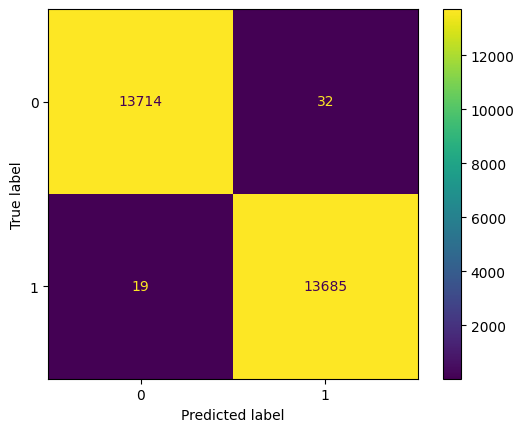

In [172]:
tree2=DecisionTreeClassifier(max_depth=10,min_samples_split=5)

tree2.fit(x_ov,y_ov)
y_pred=tree2.predict(x_test)
print('Testing score:',tree2.score(x_test,y_test))
print('Training score:',tree2.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [173]:
tree2_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',tree2_acc)

accuracy score: 0.9981420765027322


## Random Forest

In [174]:
par={'n_estimators':[10,50,100],'max_depth':[None,10,20]}
rft=GridSearchCV(model,par,cv=5,scoring='accuracy')
rft.fit(x_ov,y_ov)
print(rft.best_params_)

{'max_depth': None, 'n_estimators': 50}


Testing score: 1.0
Training score: 1.0
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13746
           1       1.00      1.00      1.00     13704

    accuracy                           1.00     27450
   macro avg       1.00      1.00      1.00     27450
weighted avg       1.00      1.00      1.00     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5EB56E0F0>


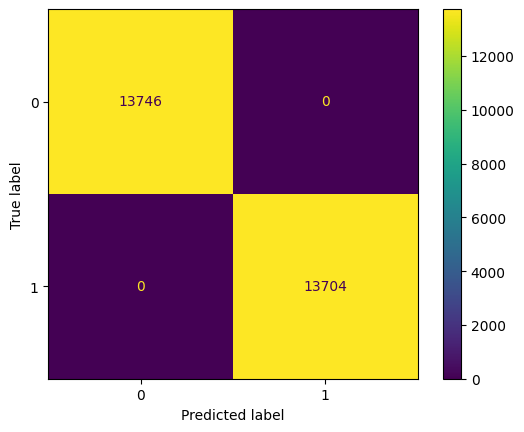

In [175]:
model2=RandomForestClassifier(n_estimators=50,max_depth=None)

model2.fit(x_ov,y_ov)
y_pred=model2.predict(x_test)
print('Testing score:',model2.score(x_test,y_test))
print('Training score:',model2.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [176]:
model2_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',model2_acc)

accuracy score: 1.0


## Ada Boost Classifier

In [188]:
par={'n_estimators':[50,100,150],'learning_rate':[0.01,0.05,0.1,0.5]}
adt=GridSearchCV(ada,par,cv=5,scoring='accuracy',n_jobs=-1)
adt.fit(x_ov,y_ov)
print(adt.best_params_)

{'learning_rate': 0.5, 'n_estimators': 150}


Testing score: 0.9951548269581056
Training score: 0.9950054644808743
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     13746
           1       0.99      1.00      1.00     13704

    accuracy                           1.00     27450
   macro avg       1.00      1.00      1.00     27450
weighted avg       1.00      1.00      1.00     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5E034F4D0>


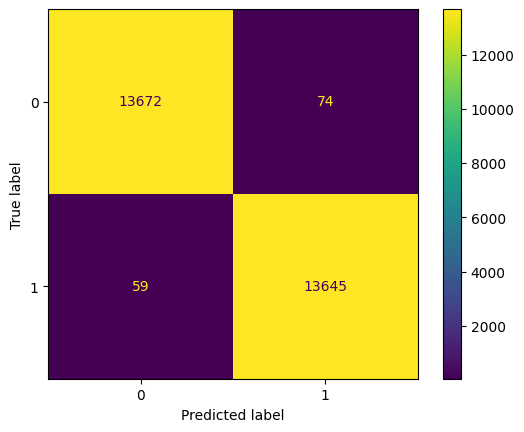

In [189]:
ada2=AdaBoostClassifier(n_estimators=150,learning_rate=0.5,random_state=42)
ada2.fit(x_ov,y_ov)
y_pred=ada2.predict(x_test)

print('Testing score:',ada2.score(x_test,y_test))
print('Training score:',ada2.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [190]:
ada2_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',ada2_acc)

accuracy score: 0.9951548269581056


## Gradient Boost Classifier

In [191]:
par={'n_estimators':[100,200],'learning_rate':[0.01,0.05,0.1]}
gbt=GridSearchCV(gbc,par,cv=3,scoring='accuracy',n_jobs=-1)
gbt.fit(x_ov,y_ov)
print(gbt.best_params_)

{'learning_rate': 0.1, 'n_estimators': 200}


Testing score: 0.9975956284153006
Training score: 0.9978360655737705
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13746
           1       1.00      1.00      1.00     13704

    accuracy                           1.00     27450
   macro avg       1.00      1.00      1.00     27450
weighted avg       1.00      1.00      1.00     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5E030B450>


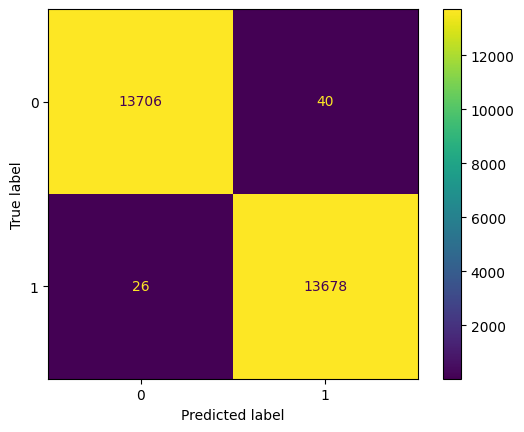

In [192]:
gbc2=GradientBoostingClassifier(learning_rate=0.1,n_estimators=200,random_state=8)
gbc2.fit(x_ov,y_ov)
y_pred=gbc2.predict(x_test)

print('Testing score:',gbc2.score(x_test,y_test))
print('Training score:',gbc2.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [193]:
gbc2_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',gbc2_acc)

accuracy score: 0.9975956284153006


## XGB Classifier

In [194]:
par={"n_estimators":[100,200],"learning_rate":[0.01,0.1,0.3]}
xgt=GridSearchCV(xgb,par,cv=5,scoring="accuracy") 
xgt.fit(x_ov,y_ov)
print(xgt.best_params_)

{'learning_rate': 0.3, 'n_estimators': 100}


Testing score: 0.9998907103825136
Training score: 0.9999672131147541
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13746
           1       1.00      1.00      1.00     13704

    accuracy                           1.00     27450
   macro avg       1.00      1.00      1.00     27450
weighted avg       1.00      1.00      1.00     27450

Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000002D5EB65AC50>


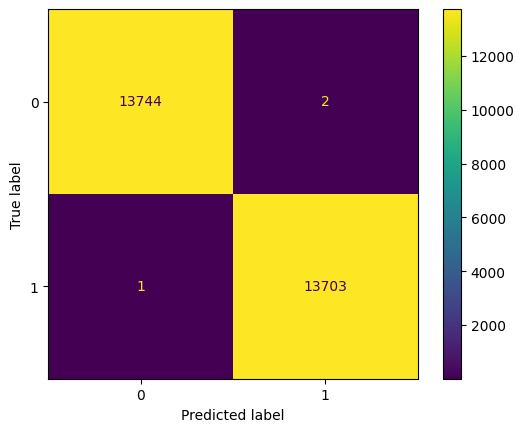

In [195]:
xgb2=XGBClassifier(n_estimators=100,learning_rate=0.3,random_state=20)
xgb2.fit(x_ov,y_ov)
y_pred=xgb2.predict(x_test)

print('Testing score:',xgb2.score(x_test,y_test))
print('Training score:',xgb2.score(x_ov,y_ov))
print('Classification report:\n',classification_report(y_test,y_pred))
print('Confusion Matrix:',ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [196]:
xgb2_acc=accuracy_score(y_test,y_pred)
print('accuracy score:',xgb2_acc)

accuracy score: 0.9998907103825136


In [197]:
tbb=pd.DataFrame()
tbb['Model']=pd.Series(['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier','AdaBoostClassifier','GradientBoostingClassifier','XGBClassifier','KNeighborsClassifier','GaussianNB','SVC'])
tbb['Accuracy']=pd.Series([log_acc,knn_acc,svm_acc,nb_acc,tree_acc,model_acc,ada_acc,gbc_acc,xgb_acc])
tbb['Accuracy_oversampling']=pd.Series([log1_acc,knn1_acc,svm1_acc,nb1_acc,tree1_acc,model1_acc,ada1_acc,gbc1_acc,xgb1_acc])
tbb['Accuracy after tuning']=pd.Series([log2_acc,knn2_acc,nb2_acc,tree2_acc,model2_acc,ada2_acc,gbc2_acc,xgb2_acc])
tbb.sort_values(by=['Accuracy after tuning'],ascending=False).reset_index(drop=True)

NameError: name 'svm1_acc' is not defined

### TEST AND TRAIN ACCURACY

In [ ]:
logtrain=log2.score(x_ov,y_ov)
dttrain=tree2.score(x_ov,y_ov)
rftrain=model2.score(x_ov,y_ov)
adatrain=ada2.score(x_ov,y_ov)
gbtrain=gbc2.score(x_ov,y_ov)
xgbtrain=xgb2.score(x_ov,y_ov)
knntrain=knn2.score(x_ov,y_ov)
nbtrain=nb2.score(x_ov,y_ov)
svctrain=svm1.score(x_ov,y_ov)

In [ ]:
tb1=pd.DataFrame()
tb1['Model']=pd.Series(['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier','AdaBoostClassifier','GradientBoostingClassifier','XGBClassifier','KNeighborsClassifier','GaussianNB'])
tb1['Test Accuracy']=pd.Series([log2_acc,tree2_acc,model2_acc,ada2_acc,gbc2_acc,xgb2_acc,knn2_acc,nb2_acc,svm1_acc])
tb1['Train Accuracy']=pd.Series([logtrain,dttrain,rftrain,adatrain,gbtrain,xgbtrain,knntrain,nbtrain,svctrain])
tb1.sort_values(by= ['Test Accuracy', 'Train Accuracy'], ascending=False).reset_index(drop=True)

## SAVING

In [ ]:
import joblib
joblib.dump(xgb2,r'credit_card_fraud_dataset-5.pkl')
joblib.dump(le1,r'le1.pkl')
joblib.dump(le2,r'le2.pkl')
joblib.dump(sd,r'sd.pkl')